# CURIA single-gene debug

Set **one** gene/transcript at the top, pin the input files, run top-to-bottom. It reproduces the pipeline **per gene** so you can see exactly where a gene like NEAT1 succeeds or fails.

**Stage A — reference island *finding* (no chain needed):** sequence -> per-window signal/noise probability track -> islands. This is the stage where NEAT1 returns 0 islands, so it's the default focus.

**Stage B — matching (optional, needs chain + query 2bit):** left as a clearly-marked extension at the bottom.

All the real work is inline (not hidden in a module) so you can tweak windows/stride/threshold and re-run. The recipe mirrors `modules/pipeline/reference_islands_scanner.py` + the GPU executor exactly: normalize (T->U) -> tokenize -> embed -> drop CLS token -> mean-pool per window -> finding-PCA(64) -> logreg -> smooth -> threshold -> label.

In [9]:
# ============ CONFIG — edit this cell ============
from pathlib import Path

REPO = Path('..')

# --- what to debug ---
TARGET = 'NEAT1'          # gene name (see NAME2ENSG), a transcript id ('U_ENSG00000245532.13'), or a bare ENSG
MODEL  = 'rinalmo'        # 'rinalmo' or 'rnafm'

# --- a COMPLETED run to compare against (Stage 0 asks: where did the gene drop?) ---
RUN_DIR = REPO / 'rinalmo_version_outputs/hg38_vs_mm39'

# --- reference inputs (Stage A needs only these two) ---
REF_2BIT  = REPO / 'input_data/2bit/hg38.2bit'
UNION_BED = RUN_DIR / 'reference_union_transcripts.bed'
UNION_META = RUN_DIR / 'reference_union_transcripts_metadata.tsv'

# --- query inputs (Stage B / matching only) ---
QUERY_2BIT = REPO / 'input_data/2bit/mm39.2bit'
CHAIN      = REPO / 'input_data/chains/hg38.mm39.allfilled.chain.gz'

# --- scan knobs: None = use the model's registry defaults; override to experiment ---
WINDOW_OVERRIDE = None    # e.g. 128
STRIDE_OVERRIDE = None    # e.g. 40
PROB_OVERRIDE   = None    # e.g. 0.5  (lower this to probe near-misses)
SMOOTH_WINDOW   = 5

# convenience name -> ENSG for the marquee lncRNAs
NAME2ENSG = {'MALAT1':'ENSG00000251562','NEAT1':'ENSG00000245532','XIST':'ENSG00000229807',
             'HOTAIR':'ENSG00000228630','H19':'ENSG00000130600','MEG3':'ENSG00000214548',
             'GAS5':'ENSG00000234741','BISPR':'ENSG00000282851','KCNQ1OT1':'ENSG00000269821',
             'XACT':'ENSG00000241743'}
print('target:', TARGET, '| model:', MODEL)

target: NEAT1 | model: rinalmo


In [2]:
# ============ imports + load model, PCA, logreg ============
import sys, time
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, str(REPO))
from pyrion import TwoBitAccessor, Strand
from pyrion.io.bed import read_bed12_file
from modules.model_registry import (load_model, get_finding_pca_path, get_logreg_path,
                                    get_island_scan_params)
from modules.GPU_executor.gpu_executor import PCAProjector, get_device, _normalize_sequence
from modules.logreg_signal_noise.apply_logreg import load_logreg_model, score_embeddings
from modules.utils.signal_processing import smooth_signal
from modules.pipeline.reference_islands_scanner import (_extract_exonic_sequence, _get_islands,
                                                       _map_spliced_to_genomic)

DEVICE = get_device('auto')
print('device:', DEVICE)
t0 = time.time()
model, tokenize_fn, extract_fn = load_model(MODEL, DEVICE)
model_eval = getattr(model, 'eval', lambda: None)()
pca_find = PCAProjector(get_finding_pca_path(MODEL), DEVICE)
logreg = load_logreg_model(str(get_logreg_path(MODEL)))
SCAN = get_island_scan_params(MODEL)
WINDOW = WINDOW_OVERRIDE or SCAN['window_size']
STRIDE = STRIDE_OVERRIDE or SCAN['stride']
PROB   = PROB_OVERRIDE if PROB_OVERRIDE is not None else SCAN['prob_threshold']
print(f'loaded {MODEL} in {time.time()-t0:.1f}s | scan: window={WINDOW} stride={STRIDE} prob>={PROB} smooth={SMOOTH_WINDOW}')

device: mps
loaded rinalmo in 4.3s | scan: window=128 stride=40 prob>=0.5 smooth=5


In [4]:
# ============ resolve TARGET -> reference union transcript ============
import pandas as pd
union = read_bed12_file(str(UNION_BED))
all_ids = [t.id for t in union]

def resolve_target(target):
    ensg = NAME2ENSG.get(target, target)                 # name -> ENSG if known
    cands = [f'U_{ensg}', ensg, f'U_{target}', target]    # try a few spellings
    for c in cands:
        if c in all_ids:
            return c
    for pref in (f'U_{ensg}', f'U_{target}', ensg, target):  # prefix (version-agnostic)
        hit = [i for i in all_ids if i == pref or i.startswith(pref + '.')]
        if hit:
            return hit[0]
    return None

uid = resolve_target(TARGET)
assert uid is not None, f'{TARGET!r} not found in {UNION_BED.name} ({len(all_ids):,} transcripts)'
tx = union.get_by_id(uid)
chrom = tx.chrom
strand = int(getattr(tx.strand, 'value', tx.strand))       # +1 / -1 (Strand enum or int)
exon_blocks = [(int(s), int(e)) for s, e in tx.exons()]
span = int(tx.end) - int(tx.start)
exon_bp = sum(e - s for s, e in exon_blocks)

meta = pd.read_csv(UNION_META, sep='\t')
bt = meta.loc[meta.transcript_id == uid, 'biotype']
biotype = bt.iloc[0] if len(bt) else 'unknown'

print(f'resolved TARGET={TARGET!r} -> {uid}')
print(f'  biotype   : {biotype}')
print(f'  locus     : {chrom}:{int(tx.start):,}-{int(tx.end):,}  strand {"+" if strand==1 else "-"}')
print(f'  span      : {span:,} bp   exons: {len(exon_blocks)}   spliced length: {exon_bp:,} bp')

resolved TARGET='NEAT1' -> U_ENSG00000245532.13
  biotype   : lncRNA
  locus     : chr11:65,422,797-65,445,540  strand +
  span      : 22,743 bp   exons: 1   spliced length: 22,743 bp


In [10]:
# ============ Stage 0 — where did this gene drop in RUN_DIR? (localise the failure) ============
# Walk the pipeline's own outputs in order; the first 'NO' is where the gene was lost.
import json
base = uid.split('.')[0].replace('U_', '')      # ENSG without version

def _has(path, needle):
    try:
        return any(needle in ln for ln in open(path))
    except FileNotFoundError:
        return None

toga_tbl = RUN_DIR / 'toga_results' / 'original_toga_classification_table.tsv'
ortho = RUN_DIR / 'toga_results' / 'rna_orthologous_regions.tsv'
u2q = RUN_DIR / 'mappings' / 'union_to_query.json'
pre = RUN_DIR / 'preprocessed_reference_data.json'
aln = RUN_DIR / 'query_annotation' / 'island_alignment_results.tsv'
if not aln.exists():
    aln = RUN_DIR / 'island_alignment_results.tsv'

# TOGA orthology classification row (why the orthology gate accepted/rejected it)
toga_row = None
if toga_tbl.exists():
    tdf = pd.read_csv(toga_tbl)
    hit = tdf[tdf.transcript_id.astype(str).str.contains(base)]
    if len(hit):
        toga_row = hit.iloc[0]

u2q_data = json.load(open(u2q)) if u2q.exists() else {}
in_u2q = any(base in k for k in u2q_data)
prep = json.load(open(pre)) if pre.exists() else {}
in_prep = any(base in k for k in prep)

steps = [
    ('in reference union',            base in uid),
    ('TOGA classified (raw table)',   _has(toga_tbl, base)),
    ('passed orthology gate (ortho regions)', _has(ortho, base)),
    ('has query region (union_to_query)',     in_u2q),
    ('reference islands found (preprocessed)', in_prep),
    ('reached final alignment',       _has(aln, base)),
]
print(f'PIPELINE FATE of {uid} in {RUN_DIR.name}:')
for label, ok in steps:
    mark = '??' if ok is None else ('OK ' if ok else 'NO ')
    print(f'  [{mark}] {label}')
if toga_row is not None:
    print(f"\nTOGA orthology call: pred={float(toga_row['pred']):.3f}  label={toga_row['label']}  "
          f"single_exon={toga_row['single_exon']}  ex_num={toga_row['ex_num']}  exon_perc={float(toga_row['exon_perc']):.3f}")
first_no = next((l for l, ok in steps if ok is False), None)
print(f"\n>>> First failure: {first_no or 'none — gene survives to final output'}")

PIPELINE FATE of U_ENSG00000245532.13 in hg38_vs_mm39:
  [OK ] in reference union
  [OK ] TOGA classified (raw table)
  [NO ] passed orthology gate (ortho regions)
  [NO ] has query region (union_to_query)
  [NO ] reference islands found (preprocessed)
  [NO ] reached final alignment

TOGA orthology call: pred=0.275  label=PARA  single_exon=1  ex_num=1  exon_perc=0.411

>>> First failure: passed orthology gate (ortho regions)


In [12]:
# ============ Stage 0.5 — orthology decision: dissect the chain features + both models ============
# When Stage 0's first failure is the orthology gate, this shows WHY. All features are
# chain-derived and model-independent; only the classifier differs between runs.
from modules.rna_toga.rna_toga import classify_table
from modules.model_registry import get_rna_toga_model_path
import json as _json

RNA_TOGA_DIR = REPO / 'modules' / 'rna_toga'
toga_tbl_p = RUN_DIR / 'toga_results' / 'original_toga_classification_table.tsv'
tdf = pd.read_csv(toga_tbl_p)
grows = tdf[tdf.transcript_id.astype(str).str.contains(base)].copy()
if len(grows) == 0:
    print(f'{base} not in classification table (was it even lifted by a chain?).')
else:
    feat_cols = ['chain_id','gl_exo','exlen_to_qlen','synteny','flank_cov','exon_perc','ex_num','single_exon']
    print(f'{base}: {len(grows)} chain(s) classified. Chain-derived features:')
    print(grows[[c for c in feat_cols if c in grows.columns]].to_string(index=False))

    # transparent logreg breakdown (uses only synteny_log1p, gl_exo, flank_cov)
    coeffs = _json.load(open(RNA_TOGA_DIR / 'model.json'))['coefficients']
    r = grows.iloc[0]
    parts = {'synteny_log1p': coeffs['synteny_log1p'] * np.log1p(r['synteny']),
             'gl_exo':        coeffs['gl_exo'] * r['gl_exo'],
             'flank_cov':     coeffs['flank_cov'] * r['flank_cov'],
             'intercept':     coeffs['intercept']}
    print('\nlogreg score contributions (top chain):')
    for k, v in parts.items():
        print(f'  {k:14s} {v:+.3f}')
    print(f'  {"= score":14s} {sum(parts.values()):+.3f}')

    # score with BOTH orthology models
    inp = grows[['chain_id','transcript_id','gl_exo','exlen_to_qlen','synteny','flank_cov','exon_perc','ex_num','biotype']]
    print('\nper-model verdict (top chain):')
    for mp, tag in [(RNA_TOGA_DIR/'model.json','logreg (rnafm default)'),
                    (RNA_TOGA_DIR/'gbm_model.json','GBM (rinalmo default)')]:
        res = classify_table(inp, str(mp)).iloc[0]
        print(f'  {tag:26s} pred={float(res.pred):.3f}  label={res.label}')
    used = get_rna_toga_model_path(MODEL).name
    print(f"\nthis run ({MODEL}) used: {used}")
    print('features are identical for both models -> any ORTH/PARA disagreement is purely the classifier.')

ENSG00000245532: 1 chain(s) classified. Chain-derived features:
 chain_id   gl_exo  exlen_to_qlen  synteny  flank_cov  exon_perc  ex_num  single_exon
       74 0.497491        0.22904      121    0.16675   0.411072       1            1

logreg score contributions (top chain):
  synteny_log1p  +3.711
  gl_exo         -3.849
  flank_cov      +2.364
  intercept      +0.078
  = score        +2.304

per-model verdict (top chain):
  logreg (rnafm default)     pred=0.909  label=ORTH
  GBM (rinalmo default)      pred=0.275  label=PARA

this run (rinalmo) used: gbm_model.json
features are identical for both models -> any ORTH/PARA disagreement is purely the classifier.


In [13]:
# ============ Stage 0.6 — which GBM feature is holding this gene down? (local sensitivity) ============
# Sweep one feature at a time, holding the rest at this gene's values, and watch the GBM pred.
# NOTE: this is LOCAL sensitivity on the FROZEN model. It shows what the current model keys on,
# NOT what a retrain would do (correlated features let a retrain re-compensate; see the ablation notes).
if len(grows):
    gbm_path = str(RNA_TOGA_DIR / 'gbm_model.json')
    r0 = grows.iloc[0]
    fixed = dict(chain_id=r0['chain_id'], transcript_id=uid, biotype='lncRNA',
                 gl_exo=r0['gl_exo'], exlen_to_qlen=r0['exlen_to_qlen'], synteny=r0['synteny'],
                 flank_cov=r0['flank_cov'], exon_perc=r0['exon_perc'], ex_num=r0['ex_num'])
    lncrna_thr = 0.30
    def gpred(**ov):
        row = dict(fixed); row.update(ov)
        return float(classify_table(pd.DataFrame([row]), gbm_path).pred.iloc[0])
    base_pred = gpred()
    sweeps = {'gl_exo': [r0['gl_exo'], 0.3, 0.2, 0.1],
              'flank_cov': [r0['flank_cov'], 0.4, 0.7, 0.9],
              'exon_perc': [r0['exon_perc'], 0.6, 0.8, 1.0],
              'exlen_to_qlen': [r0['exon_perc'], 0.4, 0.6, 0.9],
              'ex_num (single->multi)': [1, 2, 3]}
    print(f'baseline GBM pred = {base_pred:.3f}  (lncRNA threshold {lncrna_thr})  [{"ORTH" if base_pred>=lncrna_thr else "PARA"}]')
    print('sweep one feature, hold rest fixed:')
    for feat, vals in sweeps.items():
        key = 'ex_num' if feat.startswith('ex_num') else feat
        cells = [f'{v}:{gpred(**{key: v}):.3f}' for v in vals]
        print(f'  {feat:24s} ' + '   '.join(cells))
    print('\nThe feature whose change lifts pred above the threshold is what the frozen model keys on for this gene.')
    print('For a single-exon lncRNA that is typically gl_exo (inflated: whole gene = one exon) and single_exon.')

baseline GBM pred = 0.275  (lncRNA threshold 0.3)  [PARA]
sweep one feature, hold rest fixed:
  gl_exo                   0.4974912010824481:0.275   0.3:0.813   0.2:0.838   0.1:0.965
  flank_cov                0.16675:0.275   0.4:0.269   0.7:0.248   0.9:0.248
  exon_perc                0.4110715384953612:0.275   0.6:0.287   0.8:0.287   1.0:0.786
  exlen_to_qlen            0.4110715384953612:0.403   0.4:0.403   0.6:0.334   0.9:0.334
  ex_num (single->multi)   1:0.275   2:0.994   3:0.994

The feature whose change lifts pred above the threshold is what the frozen model keys on for this gene.
For a single-exon lncRNA that is typically gl_exo (inflated: whole gene = one exon) and single_exon.


In [5]:
# ============ Stage A.1 — extract spliced exonic sequence from ref 2bit ============
ref_acc = TwoBitAccessor(str(REF_2BIT))
seq = _extract_exonic_sequence(ref_acc, chrom, strand, exon_blocks)
seq = _normalize_sequence(seq)                 # upper + T->U, exactly as the executor does
L = len(seq)
comp = {b: seq.count(b) for b in 'ACGU'}
n_other = L - sum(comp.values())
n_windows = max(0, (L - WINDOW) // STRIDE + 1)
print(f'spliced sequence: {L:,} nt   composition {comp}  (non-ACGU: {n_other})')
print(f'windows of {WINDOW} nt @ stride {STRIDE}  ->  {n_windows} windows')
if n_windows == 0:
    print('WARNING: sequence shorter than one window -> scanner cannot produce islands here.')

spliced sequence: 22,743 nt   composition {'A': 5509, 'C': 4646, 'G': 5373, 'U': 7215}  (non-ACGU: 0)
windows of 128 nt @ stride 40  ->  566 windows


In [6]:
# ============ Stage A.2 — embed windows -> finding PCA(64) -> logreg signal prob ============
positions = np.arange(0, L - WINDOW + 1, STRIDE)
windows = [seq[p:p + WINDOW] for p in positions]
assert len(windows) > 0, 'no windows to embed'

BATCH = 64
mean_vecs = []
t0 = time.time()
for i in range(0, len(windows), BATCH):
    chunk = windows[i:i + BATCH]
    tokens = tokenize_fn(chunk)
    with torch.no_grad():
        reps = extract_fn(model, tokens)                 # (b, Lmax, D)
    for j, w in enumerate(chunk):
        tok = reps[j, 1:1 + len(w), :]                   # drop CLS/BOS token at index 0
        mean_vecs.append(tok.mean(dim=0).float().cpu())  # mean-pool over the window
    print(f'  embedded {min(i + BATCH, len(windows))}/{len(windows)} windows', end='\r')

emb = torch.stack(mean_vecs, dim=0).to(DEVICE).float()   # (nwin, D)
emb64 = pca_find.project(emb).cpu().numpy()              # (nwin, 64)
probs, status = score_embeddings(emb64, model=logreg)    # P(signal) per window
probs_smooth = smooth_signal(probs, SMOOTH_WINDOW)
print(f'\nembedded {len(windows)} windows in {time.time() - t0:.1f}s')
print(f'raw P(signal):    min={probs.min():.3f}  median={np.median(probs):.3f}  max={probs.max():.3f}')
print(f'smoothed P(signal): min={probs_smooth.min():.3f}  median={np.median(probs_smooth):.3f}  max={probs_smooth.max():.3f}')

  embedded 566/566 windows
embedded 566 windows in 23.6s
raw P(signal):    min=0.007  median=0.388  max=0.967
smoothed P(signal): min=0.041  median=0.409  max=0.812


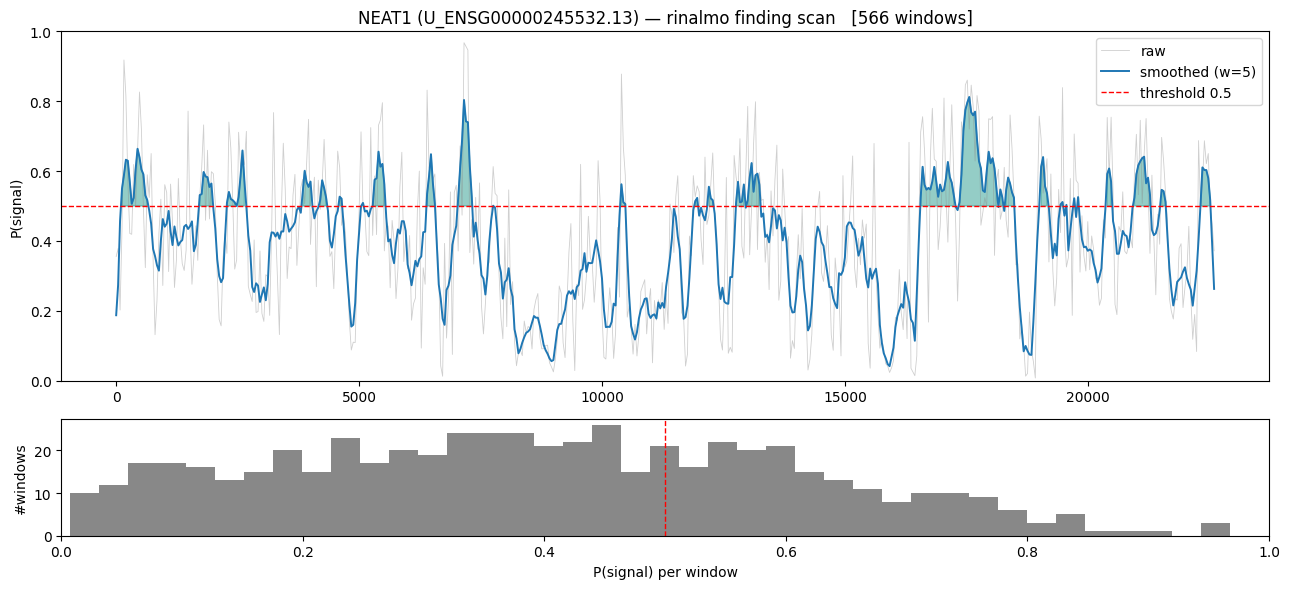

fraction of windows above candidate thresholds:
  smoothed >= 0.3:  69.8%   raw >= 0.3:  65.0%
  smoothed >= 0.4:  52.5%   raw >= 0.4:  48.9%
  smoothed >= 0.5:  27.9%   raw >= 0.5:  32.2%
  smoothed >= 0.6:   8.3%   raw >= 0.6:  17.5%
  smoothed >= 0.7:   1.8%   raw >= 0.7:   8.7%


In [7]:
# ============ Stage A.3 — the signal track (the actual diagnosis) ============
fig, ax = plt.subplots(2, 1, figsize=(13, 6), gridspec_kw={'height_ratios': [3, 1]})
ax[0].plot(positions, probs, lw=.6, alpha=.4, color='#888', label='raw')
ax[0].plot(positions, probs_smooth, lw=1.4, color='#1f77b4', label=f'smoothed (w={SMOOTH_WINDOW})')
ax[0].axhline(PROB, color='r', ls='--', lw=1, label=f'threshold {PROB}')
ax[0].fill_between(positions, PROB, probs_smooth, where=probs_smooth >= PROB, color='#2A9D8F', alpha=.5)
ax[0].set_ylim(0, 1); ax[0].set_ylabel('P(signal)')
ax[0].set_title(f'{TARGET} ({uid}) — {MODEL} finding scan   [{n_windows} windows]'); ax[0].legend(loc='upper right')
ax[1].hist(probs, bins=40, color='#888'); ax[1].axvline(PROB, color='r', ls='--', lw=1)
ax[1].set_xlabel('P(signal) per window'); ax[1].set_ylabel('#windows'); ax[1].set_xlim(0, 1)
plt.tight_layout(); plt.show()

print('fraction of windows above candidate thresholds:')
for thr in [0.3, 0.4, 0.5, 0.6, 0.7]:
    print(f'  smoothed >= {thr}: {100*(probs_smooth >= thr).mean():5.1f}%   raw >= {thr}: {100*(probs >= thr).mean():5.1f}%')

In [11]:
# ============ Stage A.4 — label islands (exactly as the pipeline) + map to genome ============
mask = probs_smooth >= PROB
islands = _get_islands(mask, positions, WINDOW)
for isl in islands:
    isl['max_prob'] = float(np.max(probs_smooth[isl['indices']]))

print(f'ISLANDS the finding scan WOULD produce at prob>={PROB}: {len(islands)}')
for k, isl in enumerate(islands):
    segs = _map_spliced_to_genomic(exon_blocks, strand, isl['start'], isl['end'])
    span_txt = ', '.join(f'{chrom}:{s:,}-{e:,}' for s, e in segs)
    print(f'  island {k}: spliced {isl["start"]}-{isl["end"]} ({isl["end"]-isl["start"]} nt)  maxP={isl["max_prob"]:.3f}  ->  {span_txt}')

# ---- auto-diagnosis ----
mx = float(probs_smooth.max())
print('\nDIAGNOSIS:')
if len(islands) > 0:
    print(f'  Finding is HEALTHY here: the scan produces {len(islands)} island(s) from the sequence alone.')
    print(f'  So if this gene is missing from the run (see Stage 0), the loss is NOT the finding scanner.')
    print(f'  -> Look at the FIRST failure Stage 0 reported: most often the orthology gate')
    print(f'     (rna_toga classifier) dropping the gene before it is ever scanned, or matching (Stage B).')
elif mx < PROB:
    gap = PROB - mx
    print(f'  0 islands: peak smoothed P(signal)={mx:.3f} is BELOW threshold {PROB} (gap {gap:.3f}).')
    if mx >= PROB - 0.15:
        print(f'  -> NEAR MISS: a modest threshold/stride change would recover it. Try PROB_OVERRIDE below {mx:.2f}.')
    else:
        print(f'  -> FLAT/LOW signal everywhere: the finding PCA-64 + logreg barely responds to this gene.')
else:
    print('  0 islands despite windows above threshold — check smoothing/labeling params.')

ISLANDS the finding scan WOULD produce at prob>=0.5: 23
  island 0: spliced 120-768 (648 nt)  maxP=0.664  ->  chr11:65,422,917-65,423,565
  island 1: spliced 1720-2088 (368 nt)  maxP=0.597  ->  chr11:65,424,517-65,424,885
  island 2: spliced 2280-2768 (488 nt)  maxP=0.659  ->  chr11:65,425,077-65,425,565
  island 3: spliced 3840-4128 (288 nt)  maxP=0.601  ->  chr11:65,426,637-65,426,925
  island 4: spliced 4200-4448 (248 nt)  maxP=0.573  ->  chr11:65,426,997-65,427,245
  island 5: spliced 4600-4768 (168 nt)  maxP=0.527  ->  chr11:65,427,397-65,427,565
  island 6: spliced 5080-5208 (128 nt)  maxP=0.509  ->  chr11:65,427,877-65,428,005
  island 7: spliced 5280-5648 (368 nt)  maxP=0.655  ->  chr11:65,428,077-65,428,445
  island 8: spliced 6400-6688 (288 nt)  maxP=0.648  ->  chr11:65,429,197-65,429,485
  island 9: spliced 7040-7448 (408 nt)  maxP=0.803  ->  chr11:65,429,837-65,430,245
  island 10: spliced 7760-7888 (128 nt)  maxP=0.501  ->  chr11:65,430,557-65,430,685
  island 11: spliced 

---
## Stage B — matching (optional; needs `CHAIN` + `QUERY_2BIT`)

Stage A above is self-contained and needs no chain. If a gene *does* get reference islands but still vanishes from the final output, the problem is downstream: liftover of the reference islands through the chain, the query-side scan, or the island alignment. That path is heavier (chain projection + a second scan) and is deliberately left out here — reference finding is the current NEAT1 bottleneck.

To extend: read the chain with `pyrion.read_chain_file(str(CHAIN), min_score=25_000)`, project the reference-island genomic segments (from Stage A.4) into the query with pyrion's chain projection, extract the query sequence from `QUERY_2BIT`, re-run the same embed->finding scan on the query window, then align ref vs query islands with the model's matcher in `modules/pipeline/matchers/`. Ask and I'll wire it in as Stage B cells.